# Explainable-by-Design Speech Emotion Recognition

This notebook implements an audio-only speech emotion recognition pipeline on the MELD dataset.

The project compares two modeling strategies:

1. **Black-box baseline:** a classifier trained directly on frozen HuBERT speech embeddings.
2. **Concept Bottleneck Model (CBM):** HuBERT embeddings are mapped to interpretable acoustic proxy concepts, and the final emotion classifier uses these concepts as its input.

The evaluation covers predictive performance, concept predictability, concept-level SHAP explanations, faithfulness through concept ablation, and targeted concept interventions.


In [1]:
# Install required system and Python dependencies when running in Colab.
# Local environments should be prepared manually before execution.

import sys

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

if IN_COLAB:
    !apt-get update -qq
    !apt-get install -y -qq ffmpeg
    !pip install -q --upgrade pip
    !pip install -q transformers datasets accelerate librosa soundfile shap xgboost
else:
    print("Not running in Colab. If local packages are missing, install them manually.")


Running in Colab: True
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.7 MB/s eta 0:00:00


In [2]:
# Mount Google Drive in Colab and locate the project workspace.
# The workspace is selected to maximize reuse of cached data, embeddings, and results.

from pathlib import Path
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    MYDRIVE = Path('/content/drive/MyDrive')
    LOCAL_WORK_DIR = Path('/content/XAI_MELD_Project')
else:
    MYDRIVE = Path.cwd()
    LOCAL_WORK_DIR = Path.cwd() / '.local_work'

# ---------------------------------------------------------------------
# Optional manual project-path override
# ---------------------------------------------------------------------
# If auto-detection fails, set the folder that contains the project files and caches.
# Example paths:
# USER_PROJECT_DIR_OVERRIDE = Path('/content/drive/MyDrive/XAI_MELD_Project')
# USER_PROJECT_DIR_OVERRIDE = Path('/content/drive/MyDrive/meld_ssl_cbm_xai')
USER_PROJECT_DIR_OVERRIDE = None


def first_existing_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None

# Auto-detect likely project roots from the configured workspace.
# Common project folder names are checked in priority order.
project_candidates = []
if USER_PROJECT_DIR_OVERRIDE is not None:
    project_candidates.append(Path(USER_PROJECT_DIR_OVERRIDE))
project_candidates += [
    MYDRIVE / 'XAI_MELD_Project',
    MYDRIVE / 'meld_ssl_cbm_xai',
    MYDRIVE / 'MELD_Project',
]

PROJECT_DIR = first_existing_path(project_candidates)
if PROJECT_DIR is None:
    # Default project location when no existing workspace is found.
    PROJECT_DIR = MYDRIVE / 'XAI_MELD_Project'

DRIVE_DATA_DIR = PROJECT_DIR / 'data'
DRIVE_OUTPUT_DIR = PROJECT_DIR / 'outputs'
DRIVE_MODEL_DIR = PROJECT_DIR / 'models'
LOCAL_DATA_DIR = LOCAL_WORK_DIR / 'data'
LOCAL_MELD_EXTRACT_DIR = LOCAL_DATA_DIR / 'MELD'

for p in [PROJECT_DIR, DRIVE_DATA_DIR, DRIVE_OUTPUT_DIR, DRIVE_MODEL_DIR, LOCAL_WORK_DIR, LOCAL_DATA_DIR, LOCAL_MELD_EXTRACT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
print('DRIVE_DATA_DIR:', DRIVE_DATA_DIR)
print('LOCAL_MELD_EXTRACT_DIR:', LOCAL_MELD_EXTRACT_DIR)
print('DRIVE_OUTPUT_DIR:', DRIVE_OUTPUT_DIR)


Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/XAI_MELD_Project
DRIVE_DATA_DIR: /content/drive/MyDrive/XAI_MELD_Project/data
LOCAL_MELD_EXTRACT_DIR: /content/XAI_MELD_Project/data/MELD
DRIVE_OUTPUT_DIR: /content/drive/MyDrive/XAI_MELD_Project/outputs


In [ ]:
# Optional MELD extraction and preparation.
# When a valid cached index exists, raw MELD extraction is skipped.

from pathlib import Path
import os
import tarfile
import shutil

possible_cached_indexes = [
    PROJECT_DIR / 'outputs' / 'meld_ssl_cbm_xai' / 'meld_audio_index_with_wavs.csv',
    PROJECT_DIR / 'outputs' / 'meld_ssl_cbm_xai-ver5' / 'meld_audio_index_with_wavs.csv',
    PROJECT_DIR / 'meld_ssl_cbm_xai' / 'meld_audio_index_with_wavs.csv',
    PROJECT_DIR / 'meld_audio_index_with_wavs.csv',
]
CACHED_INDEX_FOR_SETUP = next((p for p in possible_cached_indexes if p.exists()), None)

if CACHED_INDEX_FOR_SETUP is not None:
    print('Found cached MELD index, so raw MELD download/extraction is skipped:')
    print(CACHED_INDEX_FOR_SETUP)
    MELD_ROOT = None
else:
    print('No cached MELD index found. Running the original MELD download/extraction logic.')


    from pathlib import Path
    import os
    import tarfile
    import shutil

    MELD_URL = 'https://huggingface.co/datasets/declare-lab/MELD/resolve/main/MELD.Raw.tar.gz'
    MELD_ARCHIVE = DRIVE_DATA_DIR / 'MELD.Raw.tar.gz'

    # Manually extracted MELD folders in Drive are also supported.
    DRIVE_EXTRACTED_CANDIDATES = [
        DRIVE_DATA_DIR / 'MELD.Raw',
        DRIVE_DATA_DIR / 'MELD' / 'MELD.Raw',
        DRIVE_DATA_DIR / 'MELD',
    ]

    if not MELD_ARCHIVE.exists():
        print('MELD.Raw.tar.gz was not found in Google Drive.')
        print('Downloading MELD.Raw.tar.gz to:', MELD_ARCHIVE)
        print('This can take a while because the archive is large.')
        !wget -c -O "{MELD_ARCHIVE}" "{MELD_URL}"
    else:
        print('MELD archive found in Drive:', MELD_ARCHIVE)
        print('Archive size GB:', round(MELD_ARCHIVE.stat().st_size / (1024**3), 2))


    def has_required_csvs(root):
        root = Path(root)
        return (
            any(root.rglob('train_sent_emo.csv')) and
            any(root.rglob('dev_sent_emo.csv')) and
            any(root.rglob('test_sent_emo.csv'))
        )


    def count_media_files(root):
        root = Path(root)
        exts = ['*.mp4', '*.avi', '*.mov', '*.wav', '*.flac', '*.mp3', '*.m4a']
        return sum(len(list(root.rglob(ext))) for ext in exts)


    def local_meld_ready(root):
        return has_required_csvs(root) and count_media_files(root) > 0


    def safe_extract_tar(tar_path, destination):
        """Extract a tar.gz archive. In Colab this is used for the official MELD archive."""
        tar_path = Path(tar_path)
        destination = Path(destination)
        destination.mkdir(parents=True, exist_ok=True)
        print(f'Extracting {tar_path.name} -> {destination}')
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(path=destination)


    def extract_nested_archives(root, max_rounds=3):
        """Extract train.tar.gz/dev.tar.gz/test.tar.gz and any similar nested tarballs."""
        root = Path(root)
        extracted_any = False
        already_extracted_markers = set()

        for round_idx in range(max_rounds):
            nested_archives = sorted(root.rglob('*.tar.gz'))
            # Avoid extracting the main archive again if it appears in this search.
            nested_archives = [p for p in nested_archives if p.name != 'MELD.Raw.tar.gz']

            if not nested_archives:
                break

            print(f'Nested extraction round {round_idx + 1}: found {len(nested_archives)} nested .tar.gz files')
            extracted_this_round = False

            for nested_tar in nested_archives:
                marker = nested_tar.with_suffix(nested_tar.suffix + '.extracted')
                # Marker example: train.tar.gz.extracted
                if marker.exists() or str(nested_tar) in already_extracted_markers:
                    continue

                try:
                    safe_extract_tar(nested_tar, nested_tar.parent)
                    marker.write_text('extracted\n')
                    already_extracted_markers.add(str(nested_tar))
                    extracted_any = True
                    extracted_this_round = True
                except Exception as e:
                    print(f'WARNING: could not extract nested archive {nested_tar}: {e}')

            if not extracted_this_round:
                break

        return extracted_any


    # Prefer local extraction because reading many media files directly from Drive is slow.
    if local_meld_ready(LOCAL_MELD_EXTRACT_DIR):
        print('MELD is already fully extracted locally:', LOCAL_MELD_EXTRACT_DIR)
    else:
        print('Preparing local MELD extraction folder:', LOCAL_MELD_EXTRACT_DIR)
        if LOCAL_MELD_EXTRACT_DIR.exists():
            shutil.rmtree(LOCAL_MELD_EXTRACT_DIR)
        LOCAL_MELD_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

        # Extract the main archive when available.
        if MELD_ARCHIVE.exists():
            safe_extract_tar(MELD_ARCHIVE, LOCAL_MELD_EXTRACT_DIR)
        else:
            # Otherwise, copy a manually extracted Drive folder.
            copied = False
            for candidate in DRIVE_EXTRACTED_CANDIDATES:
                if candidate.exists():
                    print('Copying manually extracted MELD folder from Drive:', candidate)
                    shutil.copytree(candidate, LOCAL_MELD_EXTRACT_DIR / candidate.name, dirs_exist_ok=True)
                    copied = True
                    break
            if not copied:
                raise FileNotFoundError(
                    'Could not find MELD.Raw.tar.gz or a manually extracted MELD folder in Drive. '
                    'Expected: MyDrive/XAI_MELD_Project/data/MELD.Raw.tar.gz'
                )

        # Extract nested train/dev/test archives inside MELD.Raw.
        extract_nested_archives(LOCAL_MELD_EXTRACT_DIR)


    # Print a compact diagnostic tree.
    print('\nTop-level local extraction contents:')
    for item in sorted(LOCAL_MELD_EXTRACT_DIR.iterdir())[:30]:
        kind = 'DIR ' if item.is_dir() else 'FILE'
        print(f'- {kind}: {item.name}')

    print('\nDetected CSV files:')
    for csv in sorted(LOCAL_MELD_EXTRACT_DIR.rglob('*sent_emo.csv')):
        print('-', csv)

    media_count = count_media_files(LOCAL_MELD_EXTRACT_DIR)
    print('\nDetected media file count:', media_count)
    first_media = []
    for pattern in ['*.mp4', '*.avi', '*.mov', '*.wav', '*.flac', '*.mp3', '*.m4a']:
        first_media.extend(sorted(LOCAL_MELD_EXTRACT_DIR.rglob(pattern))[:5])
        if len(first_media) >= 5:
            break
    print('First media examples:')
    for p in first_media[:5]:
        print('-', p)


    # Auto-detect the actual MELD root.
    # The correct root contains the train/dev/test CSV files; media files may be nested below it.
    candidates = []
    for train_csv in LOCAL_MELD_EXTRACT_DIR.rglob('train_sent_emo.csv'):
        root = train_csv.parent
        if (root / 'dev_sent_emo.csv').exists() and (root / 'test_sent_emo.csv').exists():
            candidates.append(root)

    if not candidates:
        found_csvs = sorted(str(p.relative_to(LOCAL_MELD_EXTRACT_DIR)) for p in LOCAL_MELD_EXTRACT_DIR.rglob('*.csv'))
        raise FileNotFoundError(
            'Could not find train_sent_emo.csv, dev_sent_emo.csv, and test_sent_emo.csv together under '\
            f'{LOCAL_MELD_EXTRACT_DIR}.\n'
            'CSV files found were:\n- ' + '\n- '.join(found_csvs[:50]) + '\n\n'
            'If train_sent_emo.csv is missing, your MELD archive is incomplete or partially synced in Drive. '
            'Wait until Google Drive finishes uploading/syncing, or re-upload/re-download MELD.Raw.tar.gz.'
        )

    # Prefer the candidate with the most media files below it.
    MELD_ROOT = max(candidates, key=count_media_files)

    if count_media_files(MELD_ROOT) == 0:
        raise FileNotFoundError(
            f'Found MELD CSVs at {MELD_ROOT}, but found 0 media files below that folder. '
            'This means train.tar.gz/dev.tar.gz/test.tar.gz were not extracted correctly.'
        )

    print('\nDetected MELD_ROOT:', MELD_ROOT)
    print('MELD_ROOT media count:', count_media_files(MELD_ROOT))
    print('MELD_ROOT CSV check:')
    print('- train:', (MELD_ROOT / 'train_sent_emo.csv').exists())
    print('- dev  :', (MELD_ROOT / 'dev_sent_emo.csv').exists())
    print('- test :', (MELD_ROOT / 'test_sent_emo.csv').exists())


Found cached MELD index, so raw MELD download/extraction is skipped:
/content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai/meld_audio_index_with_wavs.csv


In [4]:
# Import core libraries and configure the runtime environment.

from pathlib import Path
import os
import sys
import json
import math
import hashlib
import subprocess
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

RANDOM_STATE = 5404

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils import resample

# Optional libraries are checked explicitly so missing dependencies produce clear errors.
try:
    import torch
except Exception as exc:
    torch = None
    print("PyTorch is not available:", exc)

try:
    import librosa
except Exception as exc:
    librosa = None
    print("librosa is not available:", exc)

try:
    import shap
except Exception as exc:
    shap = None
    print("SHAP is not available:", exc)

try:
    from transformers import AutoFeatureExtractor, AutoModel
except Exception as exc:
    AutoFeatureExtractor = None
    AutoModel = None
    print("transformers is not available:", exc)

pd.set_option("display.max_columns", 120)
np.random.seed(RANDOM_STATE)


In [5]:
# Global configuration.
# Cache-aware setup prioritizes existing outputs, especially the full HuBERT embedding matrix.

from pathlib import Path
import sys, shutil, os

IN_COLAB = "google.colab" in sys.modules

if 'PROJECT_DIR' not in globals():
    if IN_COLAB:
        PROJECT_DIR = Path('/content/drive/MyDrive/XAI_MELD_Project')
        LOCAL_WORK_DIR = Path('/content/XAI_MELD_Project')
    else:
        PROJECT_DIR = Path.cwd() / 'XAI_MELD_Project'
        LOCAL_WORK_DIR = Path.cwd() / '.local_work'

# Reuse cached artifacts whenever possible.
USE_CACHED_OUTPUTS = True

# Select the speech representation backbone used in the experiments.
BACKBONE_NAME = 'facebook/hubert-base-ls960'
# BACKBONE_NAME = 'facebook/wav2vec2-base'

SAMPLE_RATE = 16000
MAX_SECONDS = 12
QUICK_RUN = False
MAX_ITEMS_PER_SPLIT = 120
MIN_CLASS_COUNT = 2
LABEL_MODE = 'emotion_7class'

EMBED_MATRIX_FILENAME = (
    f'meld_ssl_embeddings_{BACKBONE_NAME.replace("/", "__")}_'
    f'{"quick" if QUICK_RUN else "full"}.npy'
)


def first_existing_path(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return None

# Candidate output folders, including legacy result locations.
# These locations are searched before recomputing embeddings.
output_candidates = [
    PROJECT_DIR / 'outputs' / 'meld_ssl_cbm_xai',
    PROJECT_DIR / 'outputs' / 'meld_ssl_cbm_xai-ver5',
    PROJECT_DIR / 'meld_ssl_cbm_xai',
    PROJECT_DIR,
]

# Prefer a folder containing the full embedding matrix.
existing_output_with_matrix = first_existing_path([
    p for p in output_candidates
    if (p / EMBED_MATRIX_FILENAME).exists()
])

# Otherwise, use a folder containing the cached index and intermediate results.
existing_output_with_index_or_results = first_existing_path([
    p for p in output_candidates
    if (p / 'meld_audio_index_with_wavs.csv').exists() or (p / 'blackbox_vs_explainable_comparison.csv').exists()
])

# Canonical output folder for this notebook.
CANONICAL_OUTPUT_DIR = PROJECT_DIR / 'outputs' / 'meld_ssl_cbm_xai'

# If the matrix exists elsewhere, copy it into the canonical output folder.
# This avoids unnecessary per-file embedding extraction.
CANONICAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if existing_output_with_matrix is not None:
    source_matrix = existing_output_with_matrix / EMBED_MATRIX_FILENAME
    target_matrix = CANONICAL_OUTPUT_DIR / EMBED_MATRIX_FILENAME
    if source_matrix.resolve() != target_matrix.resolve() and not target_matrix.exists():
        print('Copying full embedding matrix into canonical output folder:')
        print('  from:', source_matrix)
        print('  to:  ', target_matrix)
        shutil.copy2(source_matrix, target_matrix)

    # Also copy common cached artifacts when missing, especially the index and concept files.
    for name in [
        'meld_audio_index_with_wavs.csv',
        'meld_acoustic_proxy_concepts_fast.csv',
        'blackbox_vs_explainable_comparison.csv',
        'concept_prediction_quality.csv',
        'cbm_concept_shap_importance.csv',
        'cbm_domain_alignment.csv',
        'cbm_faithfulness_ablation.csv',
        'cbm_concept_interventions.csv',
    ]:
        src = existing_output_with_matrix / name
        dst = CANONICAL_OUTPUT_DIR / name
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)

# Use the canonical output directory from this point onward.
OUTPUT_DIR = CANONICAL_OUTPUT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Detect the audio-cache root across supported project layouts:
#   MyDrive/XAI_MELD_Project/cache/meld_ssl_cbm_xai/audio_cache_wav16k
#   MyDrive/meld_ssl_cbm_xai/audio_cache_wav16k
cache_root_candidates = [
    PROJECT_DIR / 'cache' / 'meld_ssl_cbm_xai',
    PROJECT_DIR / 'outputs' / 'meld_ssl_cbm_xai',
    PROJECT_DIR / 'outputs' / 'meld_ssl_cbm_xai-ver5',
    PROJECT_DIR / 'meld_ssl_cbm_xai',
    PROJECT_DIR,
    OUTPUT_DIR,
]
CACHE_ROOT = first_existing_path([
    p for p in cache_root_candidates
    if (p / 'audio_cache_wav16k').exists() or (p / 'embedding_cache').exists()
])
if CACHE_ROOT is None:
    CACHE_ROOT = PROJECT_DIR / 'cache' / 'meld_ssl_cbm_xai'

AUDIO_CACHE = CACHE_ROOT / 'audio_cache_wav16k'
EMBEDDING_CACHE_ROOT = CACHE_ROOT / 'embedding_cache'
EMBEDDING_CACHE = EMBEDDING_CACHE_ROOT / BACKBONE_NAME.replace('/', '__')
AUDIO_CACHE.mkdir(parents=True, exist_ok=True)
EMBEDDING_CACHE.mkdir(parents=True, exist_ok=True)

# Detect MELD_ROOT only when raw media access is required.
# A valid cached index allows later stages to run without raw media paths.
cached_index_path = OUTPUT_DIR / 'meld_audio_index_with_wavs.csv'
if 'MELD_ROOT' not in globals():
    possible_roots = []
    if IN_COLAB:
        possible_roots += list(Path('/content/XAI_MELD_Project/data/MELD').rglob('train_sent_emo.csv'))
    possible_roots += list((PROJECT_DIR / 'data').rglob('train_sent_emo.csv'))
    possible_roots += list((OUTPUT_DIR).rglob('train_sent_emo.csv'))
    if possible_roots:
        MELD_ROOT = possible_roots[0].parent
    elif cached_index_path.exists():
        MELD_ROOT = None
        print('MELD_ROOT not found, but cached MELD index exists, so raw media discovery can be skipped.')
    else:
        raise RuntimeError(
            'MELD_ROOT is not set and no cached meld_audio_index_with_wavs.csv was found. '
            'Either run the extraction cell with MELD.Raw.tar.gz, or place your previous results folder in Drive.'
        )

print('Running in Colab:', IN_COLAB)
print('PROJECT_DIR:', PROJECT_DIR)
print('MELD_ROOT:', MELD_ROOT)
print('Output directory:', OUTPUT_DIR)
print('Cache root:', CACHE_ROOT)
print('Audio cache:', AUDIO_CACHE, '| existing WAVs:', len(list(AUDIO_CACHE.glob('*.wav'))))
print('Embedding cache:', EMBEDDING_CACHE, '| existing NPYs:', len(list(EMBEDDING_CACHE.glob('*.npy'))))
print('Full embedding matrix:', OUTPUT_DIR / EMBED_MATRIX_FILENAME, '| exists:', (OUTPUT_DIR / EMBED_MATRIX_FILENAME).exists())
print('Backbone:', BACKBONE_NAME)
print('Quick run:', QUICK_RUN)


Running in Colab: True
PROJECT_DIR: /content/drive/MyDrive/XAI_MELD_Project
MELD_ROOT: None
Output directory: /content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai
Cache root: /content/drive/MyDrive/XAI_MELD_Project/cache/meld_ssl_cbm_xai
Audio cache: /content/drive/MyDrive/XAI_MELD_Project/cache/meld_ssl_cbm_xai/audio_cache_wav16k | existing WAVs: 13706
Embedding cache: /content/drive/MyDrive/XAI_MELD_Project/cache/meld_ssl_cbm_xai/embedding_cache/facebook__hubert-base-ls960 | existing NPYs: 21641
Full embedding matrix: /content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai/meld_ssl_embeddings_facebook__hubert-base-ls960_full.npy | exists: True
Backbone: facebook/hubert-base-ls960
Quick run: False


## Cache Behavior

The notebook is designed to be rerunnable in Colab or locally.

It first searches for cached artifacts, including the MELD audio index, converted WAV files, extracted acoustic concepts, and the full HuBERT embedding matrix. When these files are available, the notebook loads them directly to avoid unnecessary recomputation. If a required cache is missing, the corresponding extraction step is executed and the result is saved for future runs.


In [6]:
# Define utility functions used throughout the notebook.

def require(condition, message):
    if not condition:
        raise RuntimeError(message)


def stable_id(*parts):
    text = "||".join(str(p) for p in parts)
    return hashlib.md5(text.encode("utf-8")).hexdigest()


def run_ffmpeg_to_wav(input_path, output_path, sample_rate=16000):
    """Extract/convert audio to mono WAV using ffmpeg.

    Returns the WAV path on success. Raises a detailed RuntimeError on failure.
    Some MELD media files can be unreadable/corrupted after extraction; the
    conversion cell below logs and skips those files instead of crashing the run.
    """
    input_path = Path(input_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not input_path.exists():
        raise RuntimeError(f"Input media file does not exist: {input_path}")
    if input_path.stat().st_size == 0:
        raise RuntimeError(f"Input media file is empty: {input_path}")

    cmd = [
        "ffmpeg", "-y", "-hide_banner", "-loglevel", "error",
        "-i", str(input_path),
        "-ac", "1", "-ar", str(sample_rate),
        "-vn", str(output_path)
    ]
    try:
        result = subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    except FileNotFoundError as exc:
        raise RuntimeError(
            "ffmpeg was not found. In Colab run the setup cell that installs ffmpeg."
        ) from exc
    except subprocess.CalledProcessError as exc:
        if output_path.exists():
            try:
                output_path.unlink()
            except Exception:
                pass
        stderr = (exc.stderr or "").strip()
        raise RuntimeError(f"ffmpeg failed for {input_path}. ffmpeg stderr: {stderr[:1000]}") from exc

    if (not output_path.exists()) or output_path.stat().st_size == 0:
        raise RuntimeError(f"ffmpeg produced no valid WAV output for {input_path}")
    return output_path


def load_audio_16k(path, sample_rate=16000, max_seconds=12):
    require(librosa is not None, "Install librosa: pip install librosa soundfile")
    y, sr = librosa.load(path, sr=sample_rate, mono=True)
    if max_seconds is not None:
        y = y[: int(sample_rate * max_seconds)]
    if len(y) == 0:
        y = np.zeros(sample_rate, dtype=np.float32)
    return y.astype(np.float32), sample_rate


def safe_macro_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


In [7]:
# Build or load the MELD audio index.
# A cached index is preferred to preserve alignment between rows, concepts, and embeddings.

CACHED_INDEX_PATH = OUTPUT_DIR / "meld_audio_index_with_wavs.csv"

if USE_CACHED_OUTPUTS and CACHED_INDEX_PATH.exists():
    print("Loading cached MELD audio index:", CACHED_INDEX_PATH)
    meld_index = pd.read_csv(CACHED_INDEX_PATH)

    # Repair cached WAV paths when the project directory has changed.
    # This keeps previously generated caches usable across different Drive layouts.
    if "wav_path" in meld_index.columns:
        def repair_wav_path(p):
            p = Path(str(p))
            if p.exists():
                return str(p)
            candidate = AUDIO_CACHE / p.name
            if candidate.exists():
                return str(candidate)
            return str(p)
        meld_index["wav_path"] = meld_index["wav_path"].apply(repair_wav_path)

    # Ensure the label column is available for the selected label mode.
    if "label" not in meld_index.columns:
        if LABEL_MODE == "sentiment_3class" and "Sentiment" in meld_index.columns:
            meld_index["label"] = meld_index["Sentiment"].astype(str).str.lower()
        elif "Emotion" in meld_index.columns:
            meld_index["label"] = meld_index["Emotion"].astype(str).str.lower()
        else:
            raise RuntimeError("Cached index has no `label`, `Emotion`, or `Sentiment` column.")

    print("Cached index loaded:", meld_index.shape)
    display(meld_index[["split", "label", "wav_path"]].head())

else:
    require(MELD_ROOT is not None, "MELD_ROOT is required when cached index is not available.")

    SPLIT_MEDIA_DIR_CANDIDATES = {
        "train": ["train_splits", "train"],
        "dev": ["dev_splits_complete", "dev_splits", "dev"],
        "test": ["output_repeated_splits_test", "test_splits", "test"],
    }

    MEDIA_EXTENSIONS = [".mp4", ".avi", ".mov", ".mkv", ".wav"]

    def find_split_media_dir(meld_root, split_name):
        for folder_name in SPLIT_MEDIA_DIR_CANDIDATES[split_name]:
            candidate = Path(meld_root) / folder_name
            if candidate.exists():
                return candidate
        return None

    def find_meld_csv(meld_root, split_name):
        candidates = {
            "train": ["train_sent_emo.csv"],
            "dev": ["dev_sent_emo.csv"],
            "test": ["test_sent_emo.csv"],
        }[split_name]
        for name in candidates:
            p = Path(meld_root) / name
            if p.exists():
                return p
        raise FileNotFoundError(f"Could not find {split_name} metadata CSV under {meld_root}")

    def build_media_lookup(media_dir):
        lookup = {}
        if media_dir is None or not Path(media_dir).exists():
            return lookup
        for p in Path(media_dir).rglob("*"):
            if p.is_file() and p.suffix.lower() in MEDIA_EXTENSIONS:
                lookup[p.stem] = p
        return lookup

    rows = []
    missing_rows = []

    for split_name in ["train", "dev", "test"]:
        csv_path = find_meld_csv(MELD_ROOT, split_name)
        df = pd.read_csv(csv_path)
        df["split"] = split_name

        if LABEL_MODE == "sentiment_3class" and "Sentiment" in df.columns:
            df["label"] = df["Sentiment"].astype(str).str.lower()
        else:
            df["label"] = df["Emotion"].astype(str).str.lower()

        if LABEL_MODE == "emotion_4class":
            keep = {"anger", "joy", "neutral", "sadness"}
            df = df[df["label"].isin(keep)].copy()

        media_dir = find_split_media_dir(MELD_ROOT, split_name)
        require(media_dir is not None, f"Could not find media directory for split={split_name} under {MELD_ROOT}")
        lookup = build_media_lookup(media_dir)

        for _, r in df.iterrows():
            stem = f"dia{int(r['Dialogue_ID'])}_utt{int(r['Utterance_ID'])}"
            media_path = lookup.get(stem)
            item = r.to_dict()
            item["media_stem"] = stem
            item["media_folder"] = str(media_dir)
            item["media_path"] = str(media_path) if media_path is not None else None
            if media_path is None:
                missing_rows.append(item)
            else:
                rows.append(item)

    meld_index = pd.DataFrame(rows)

    if QUICK_RUN:
        meld_index = (
            meld_index
            .groupby(["split", "label"], group_keys=False)
            .head(MAX_ITEMS_PER_SPLIT)
            .reset_index(drop=True)
        )

    missing_df = pd.DataFrame(missing_rows)
    missing_df.to_csv(OUTPUT_DIR / "missing_media_rows.csv", index=False)
    meld_index.to_csv(OUTPUT_DIR / "meld_audio_index.csv", index=False)

    print("Indexed usable MELD media rows:", meld_index.shape)
    print("Missing media rows:", missing_df.shape)
    display(meld_index[["split", "label", "media_path"]].head())
    display(meld_index.groupby(["split", "label"]).size().unstack(fill_value=0))


Loading cached MELD audio index: /content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai/meld_audio_index_with_wavs.csv
Cached index loaded: (13706, 17)


,split,label,wav_path
0,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
1,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
2,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
3,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
4,train,surprise,/content/drive/MyDrive/XAI_MELD_Project/cache/...


In [8]:
# Convert MELD media files to 16 kHz mono WAV format.
# Existing valid WAV files are reused to avoid repeated conversion.

from tqdm.auto import tqdm

CONVERSION_FAILURE_CSV = OUTPUT_DIR / "ffmpeg_failed_media.csv"

if USE_CACHED_OUTPUTS and "wav_path" in meld_index.columns:
    existing = meld_index["wav_path"].astype(str).apply(lambda p: Path(p).exists())
    if existing.mean() >= 0.98:
        print(f"Using cached WAV paths from index: {existing.sum()}/{len(existing)} files exist.")
        before = len(meld_index)
        meld_index = meld_index[existing].reset_index(drop=True)
        after = len(meld_index)
        print(f"Usable samples after cached-WAV check: {after}/{before}")
        meld_index.to_csv(OUTPUT_DIR / "meld_audio_index_with_wavs.csv", index=False)
    else:
        print(f"Only {existing.sum()}/{len(existing)} cached WAV paths exist. Falling back to conversion if media_path is available.")

if not ("wav_path" in meld_index.columns and meld_index["wav_path"].astype(str).apply(lambda p: Path(p).exists()).mean() >= 0.98):
    require("media_path" in meld_index.columns, "No valid wav_path cache and no media_path column for conversion.")

    def media_to_cached_wav(media_path):
        media_path = Path(media_path)
        key = stable_id(media_path.resolve() if media_path.exists() else media_path)
        wav_path = AUDIO_CACHE / f"{key}.wav"

        # Reuse valid cached WAV files and ignore incomplete or corrupted files.
        if wav_path.exists():
            if wav_path.stat().st_size > 0:
                return wav_path
            wav_path.unlink(missing_ok=True)

        return run_ffmpeg_to_wav(media_path, wav_path, sample_rate=SAMPLE_RATE)

    wav_paths = []
    failed_rows = []

    for row in tqdm(meld_index.itertuples(index=False), total=len(meld_index), desc="Converting media to WAV"):
        try:
            wav_path = media_to_cached_wav(row.media_path)
            wav_paths.append(str(wav_path))
        except Exception as exc:
            wav_paths.append(None)
            failed_rows.append({
                "split": row.split,
                "Dialogue_ID": row.Dialogue_ID,
                "Utterance_ID": row.Utterance_ID,
                "label": row.label,
                "media_folder": getattr(row, "media_folder", None),
                "media_path": getattr(row, "media_path", None),
                "error": str(exc),
            })

    meld_index["wav_path"] = wav_paths

    if failed_rows:
        failed_df = pd.DataFrame(failed_rows)
        failed_df.to_csv(CONVERSION_FAILURE_CSV, index=False)
        print(f"WARNING: {len(failed_df)} media files failed ffmpeg conversion.")
        print(f"Failure report saved to: {CONVERSION_FAILURE_CSV}")
        display(failed_df.head(20))
    else:
        print("All media files converted successfully.")

    before = len(meld_index)
    meld_index = meld_index.dropna(subset=["wav_path"]).reset_index(drop=True)
    after = len(meld_index)
    print(f"Usable samples after WAV conversion: {after}/{before}")

    meld_index.to_csv(OUTPUT_DIR / "meld_audio_index_with_wavs.csv", index=False)

print("Cached/valid WAV files:", len(meld_index))
display(meld_index[["split", "label", "wav_path"]].head())


Using cached WAV paths from index: 13706/13706 files exist.
Usable samples after cached-WAV check: 13706/13706
Cached/valid WAV files: 13706


,split,label,wav_path
0,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
1,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
2,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
3,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
4,train,surprise,/content/drive/MyDrive/XAI_MELD_Project/cache/...


In [9]:
# Extract acoustic proxy concepts from the WAV signals.
# These are automatically derived signal descriptors, not human-annotated emotion concepts.

from tqdm.auto import tqdm

CONCEPT_CACHE_PATH = OUTPUT_DIR / "meld_acoustic_proxy_concepts_fast.csv"


def extract_acoustic_concepts(wav_path, sample_rate=16000):
    y, sr = load_audio_16k(
        wav_path,
        sample_rate=sample_rate,
        max_seconds=MAX_SECONDS
    )

    eps = 1e-8
    duration = len(y) / sr

    frame_length = int(0.025 * sr)
    hop_length = int(0.010 * sr)

    # Energy and pause-related descriptors.
    rms = librosa.feature.rms(
        y=y,
        frame_length=frame_length,
        hop_length=hop_length
    )[0]

    rms_mean = float(np.mean(rms))
    rms_std = float(np.std(rms))

    pause_threshold = max(np.percentile(rms, 20), 1e-5)
    pause_ratio = float(np.mean(rms < pause_threshold))

    # Lightweight pitch and voicing proxies.
    # This is not an exact F0 estimate; it approximates voicing behavior from zero-crossing activity and energy.
    try:
        zcr_for_proxy = librosa.feature.zero_crossing_rate(
            y,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]

        pitch_proxy_mean = float(np.mean(zcr_for_proxy))
        pitch_proxy_std = float(np.std(zcr_for_proxy))
        voiced_ratio_proxy = float(np.mean(rms > pause_threshold))

    except Exception:
        pitch_proxy_mean = 0.0
        pitch_proxy_std = 0.0
        voiced_ratio_proxy = 0.0

    # Spectral and cepstral structure.
    zcr = librosa.feature.zero_crossing_rate(
        y,
        frame_length=frame_length,
        hop_length=hop_length
    )[0]

    centroid = librosa.feature.spectral_centroid(
        y=y,
        sr=sr,
        hop_length=hop_length
    )[0]

    bandwidth = librosa.feature.spectral_bandwidth(
        y=y,
        sr=sr,
        hop_length=hop_length
    )[0]

    rolloff = librosa.feature.spectral_rolloff(
        y=y,
        sr=sr,
        hop_length=hop_length
    )[0]

    flatness = librosa.feature.spectral_flatness(
        y=y,
        hop_length=hop_length
    )[0]

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        hop_length=hop_length
    )

    # Onset rate as a speaking-rate and activity proxy.
    try:
        onset_env = librosa.onset.onset_strength(
            y=y,
            sr=sr,
            hop_length=hop_length
        )

        onsets = librosa.onset.onset_detect(
            onset_envelope=onset_env,
            sr=sr,
            hop_length=hop_length
        )

        onset_rate = float(len(onsets) / max(duration, eps))

    except Exception:
        onset_rate = 0.0

    concepts = {
        "duration": duration,
        "energy_mean": rms_mean,
        "energy_std": rms_std,
        "pause_ratio": pause_ratio,

        # Time-domain proxy concepts.
        "pitch_proxy_mean": pitch_proxy_mean,
        "pitch_proxy_std": pitch_proxy_std,
        "voiced_ratio_proxy": voiced_ratio_proxy,

        # Spectral proxy concepts.
        "zero_crossing_rate_mean": float(np.mean(zcr)),
        "spectral_centroid_mean": float(np.mean(centroid)),
        "spectral_bandwidth_mean": float(np.mean(bandwidth)),
        "spectral_rolloff_mean": float(np.mean(rolloff)),
        "spectral_flatness_mean": float(np.mean(flatness)),

        # Activity and rhythm proxy.
        "onset_rate_proxy": onset_rate,
    }

    # MFCC-based concepts.
    for i in range(mfcc.shape[0]):
        concepts[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        concepts[f"mfcc_{i+1}_std"] = float(np.std(mfcc[i]))

    return concepts


# Load cached concepts when available.
# This avoids recomputation after a runtime interruption.
if CONCEPT_CACHE_PATH.exists():
    print("Loading cached fast acoustic concepts:", CONCEPT_CACHE_PATH)
    concept_df = pd.read_csv(CONCEPT_CACHE_PATH)

else:
    concept_rows = []

    for _, row in tqdm(
        meld_index.iterrows(),
        total=len(meld_index),
        desc="Extracting fast acoustic proxy concepts"
    ):
        item = extract_acoustic_concepts(row["wav_path"])
        item["split"] = row["split"]
        item["label"] = row["label"]
        item["wav_path"] = row["wav_path"]
        concept_rows.append(item)

    concept_df = pd.DataFrame(concept_rows)

    concept_cols = [
        c for c in concept_df.columns
        if c not in {"split", "label", "wav_path"}
    ]

    concept_df[concept_cols] = (
        concept_df[concept_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    concept_df.to_csv(CONCEPT_CACHE_PATH, index=False)
    print("Saved fast acoustic concepts to:", CONCEPT_CACHE_PATH)


print("Concept matrix:", concept_df.shape)
display(concept_df.head())

# Save a backward-compatible copy for downstream cells that expect the original filename.
# This preserves compatibility with earlier notebook versions.
concept_df.to_csv(OUTPUT_DIR / "meld_acoustic_proxy_concepts.csv", index=False)
print("Also saved compatible concept file:", OUTPUT_DIR / "meld_acoustic_proxy_concepts.csv")

Loading cached fast acoustic concepts: /content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai/meld_acoustic_proxy_concepts_fast.csv
Concept matrix: (13706, 42)


,duration,energy_mean,energy_std,pause_ratio,pitch_proxy_mean,pitch_proxy_std,voiced_ratio_proxy,zero_crossing_rate_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,spectral_flatness_mean,onset_rate_proxy,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,mfcc_6_mean,mfcc_6_std,mfcc_7_mean,mfcc_7_std,mfcc_8_mean,mfcc_8_std,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,split,label,wav_path
0,5.674688,0.042877,0.032330,0.200704,0.210392,0.159717,0.799296,0.210392,2311.457515,1763.616953,4260.632152,0.065574,6.167741,-200.358658,64.917175,65.493614,58.250397,3.477153,36.706608,23.997396,24.652565,-12.733917,19.532681,3.374138,16.717873,-9.064386,13.457225,-6.285060,12.925063,2.235922,9.701479,-3.278744,11.837759,-3.325724,8.898636,0.789141,9.058831,-11.463981,10.581082,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
1,1.472000,0.045131,0.040616,0.202703,0.178193,0.140184,0.797297,0.178193,2107.032105,1874.133312,4069.362331,0.079521,6.793478,-220.535492,85.155350,76.786407,44.295967,15.891740,31.582083,21.022457,17.117876,-10.541086,18.756481,3.726344,11.437692,-23.001301,20.258301,0.307171,11.373342,-8.349680,9.488177,-0.884395,9.002041,-3.273687,7.434271,0.837808,9.906256,-2.575533,7.135677,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
2,2.944000,0.021441,0.025953,0.200000,0.168915,0.079784,0.800000,0.168915,2054.793192,1863.005671,4223.411017,0.067533,4.076087,-275.038940,91.530212,77.712967,26.048059,-8.370613,28.197218,20.794945,17.210228,-7.554360,14.705598,-1.468698,12.178393,-14.677111,10.914577,-5.563886,13.430112,4.582946,10.380357,1.719014,10.026199,-5.427892,7.046317,-2.111088,7.500422,-2.622942,6.097006,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
3,2.773312,0.038325,0.036122,0.201439,0.194137,0.154093,0.798561,0.194137,2369.599032,1936.902299,4786.701888,0.066033,5.048115,-243.897476,97.869469,56.399521,58.692497,9.794394,19.647543,19.940130,17.692028,-9.041881,24.225603,0.458233,12.280722,-11.293307,13.540550,-9.395280,12.793178,-11.303708,10.721443,0.669652,10.212653,-5.389081,11.264423,1.362807,11.288379,-4.803285,7.893546,train,neutral,/content/drive/MyDrive/XAI_MELD_Project/cache/...
4,6.485313,0.041416,0.026985,0.200308,0.179341,0.059945,0.799692,0.179341,1864.268439,1534.299035,3508.113444,0.031417,3.392281,-185.145752,85.045418,87.091820,22.272173,-46.425255,32.805698,5.532016,20.053616,-20.798780,13.320829,1.555841,10.743878,-12.422526,9.626927,-13.230656,12.025958,2.318036,7.845832,-3.797760,9.486728,-10.696027,8.045820,-6.674385,8.284881,-8.602373,8.508124,train,surprise,/content/drive/MyDrive/XAI_MELD_Project/cache/...


Also saved compatible concept file: /content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai/meld_acoustic_proxy_concepts.csv


In [10]:
# Extract or load self-supervised speech embeddings.
# The full cached embedding matrix is preferred; per-file extraction is used only as a fallback.

from tqdm.auto import tqdm
import shutil

embedding_matrix_path = OUTPUT_DIR / (
    f'meld_ssl_embeddings_{BACKBONE_NAME.replace("/", "__")}_'
    f'{"quick" if QUICK_RUN else "full"}.npy'
)

# Additional search for embedding matrices saved in legacy result folders.
if USE_CACHED_OUTPUTS and not embedding_matrix_path.exists():
    search_roots = []
    if 'PROJECT_DIR' in globals():
        search_roots += [PROJECT_DIR / 'outputs', PROJECT_DIR]
    if IN_COLAB:
        search_roots += [Path('/content/drive/MyDrive')]

    candidates = []
    for root in search_roots:
        root = Path(root)
        if root.exists():
            try:
                candidates.extend(list(root.rglob(embedding_matrix_path.name)))
            except Exception:
                pass

    candidates = [c for c in candidates if c.exists()]
    if candidates:
        print('Found full embedding matrix outside current OUTPUT_DIR:')
        print(' ', candidates[0])
        print('Copying it to:', embedding_matrix_path)
        embedding_matrix_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(candidates[0], embedding_matrix_path)

if USE_CACHED_OUTPUTS and embedding_matrix_path.exists():
    print('Loading cached full SSL embedding matrix:', embedding_matrix_path)
    X_ssl = np.load(embedding_matrix_path)
    require(
        X_ssl.shape[0] == len(meld_index),
        f'Cached embedding matrix rows ({X_ssl.shape[0]}) do not match meld_index rows ({len(meld_index)}). '
        'This usually means the cached MELD index and embedding matrix come from different runs.'
    )
    print('SSL embedding matrix:', X_ssl.shape)
    print('HuBERT extraction skipped.')

else:
    print('Full embedding matrix was not found. Falling back to per-file SSL embedding extraction.')
    print('This can be slow. If you expected cached results, stop this cell and check OUTPUT_DIR.')

    def get_device():
        if torch is None:
            return 'cpu'
        if torch.cuda.is_available():
            return 'cuda'
        if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            return 'mps'
        return 'cpu'

    def load_ssl_backbone(backbone_name):
        require(torch is not None, 'Install PyTorch first.')
        require(
            AutoFeatureExtractor is not None and AutoModel is not None,
            'Install transformers: pip install transformers'
        )

        device = get_device()

        feature_extractor = AutoFeatureExtractor.from_pretrained(backbone_name)
        model = AutoModel.from_pretrained(backbone_name)
        model.eval().to(device)

        print('Loaded:', backbone_name)
        print('Device:', device)
        if device == 'cuda':
            print('GPU:', torch.cuda.get_device_name(0))
        return feature_extractor, model, device

    feature_extractor, ssl_model, device = load_ssl_backbone(BACKBONE_NAME)

    def embedding_cache_path(wav_path):
        key = stable_id(
            BACKBONE_NAME,
            Path(wav_path).resolve() if Path(wav_path).exists() else wav_path,
            MAX_SECONDS
        )
        return EMBEDDING_CACHE / f'{key}.npy'

    @torch.no_grad()
    def compute_ssl_embedding(wav_path):
        cache_path = embedding_cache_path(wav_path)

        if cache_path.exists():
            return np.load(cache_path)

        y, sr = load_audio_16k(
            wav_path,
            sample_rate=SAMPLE_RATE,
            max_seconds=MAX_SECONDS
        )

        inputs = feature_extractor(
            y,
            sampling_rate=sr,
            return_tensors='pt',
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = ssl_model(**inputs)

        hidden = outputs.last_hidden_state
        emb = (
            hidden
            .mean(dim=1)
            .squeeze(0)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        np.save(cache_path, emb)
        return emb

    embeddings = []

    print('Starting SSL embedding extraction/loading.')
    print('Total WAV files:', len(meld_index))
    print('Existing per-file embedding cache files:', len(list(EMBEDDING_CACHE.glob('*.npy'))))

    for wav_path in tqdm(
        meld_index['wav_path'],
        total=len(meld_index),
        desc='Extracting/loading SSL embeddings'
    ):
        emb = compute_ssl_embedding(wav_path)
        embeddings.append(emb)

    X_ssl = np.vstack(embeddings)
    np.save(embedding_matrix_path, X_ssl)

    print('SSL embedding matrix:', X_ssl.shape)
    print('Saved embedding matrix:', embedding_matrix_path)


Loading cached full SSL embedding matrix: /content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai/meld_ssl_embeddings_facebook__hubert-base-ls960_full.npy
SSL embedding matrix: (13706, 768)
HuBERT extraction skipped.


In [12]:
# Select numeric concept columns and clean invalid values.

concept_cols = [
    c for c in concept_df.columns
    if c not in {"split", "label", "wav_path", "source_path", "utterance_id", "dialogue_id", "utterance"}
]

concept_df[concept_cols] = (
    concept_df[concept_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

print("Concept columns:", len(concept_cols))
print(concept_cols[:10])

Concept columns: 39
['duration', 'energy_mean', 'energy_std', 'pause_ratio', 'pitch_proxy_mean', 'pitch_proxy_std', 'voiced_ratio_proxy', 'zero_crossing_rate_mean', 'spectral_centroid_mean', 'spectral_bandwidth_mean']


In [13]:
# Prepare official MELD train/dev/test splits and model matrices.

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(meld_index["label"].astype(str))
class_names = list(label_encoder.classes_)

split = meld_index["split"].to_numpy()
train_idx = split == "train"
dev_idx = split == "dev"
test_idx = split == "test"

# If a quick-run dataset lacks a test split, use dev as a smoke-test fallback only.
if test_idx.sum() == 0 and dev_idx.sum() > 0:
    print("No test split found. Using dev as test for smoke testing. Do not use this for final report.")
    test_idx = dev_idx.copy()

require(train_idx.sum() > 0 and test_idx.sum() > 0, "Need at least train and test/dev samples.")

X_train_ssl, X_test_ssl = X_ssl[train_idx], X_ssl[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

X_train_concepts_raw = concept_df.loc[train_idx, concept_cols].to_numpy(dtype=float)
X_test_concepts_raw = concept_df.loc[test_idx, concept_cols].to_numpy(dtype=float)

print("Classes:", class_names)
print("Train:", X_train_ssl.shape, "Test:", X_test_ssl.shape)
print("Concepts:", len(concept_cols))


Classes: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
Train: (9988, 768) Test: (2610, 768)
Concepts: 39


Black-box SSL baseline metrics


,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,0.271264,0.213561,0.305775,0.231171,0.24583


              precision    recall  f1-score   support

       anger       0.30      0.32      0.31       345
     disgust       0.04      0.15      0.06        68
        fear       0.03      0.16      0.05        50
         joy       0.26      0.28      0.27       402
     neutral       0.63      0.27      0.37      1256
     sadness       0.16      0.28      0.20       208
    surprise       0.21      0.27      0.24       281

    accuracy                           0.27      2610
   macro avg       0.23      0.25      0.21      2610
weighted avg       0.42      0.27      0.31      2610



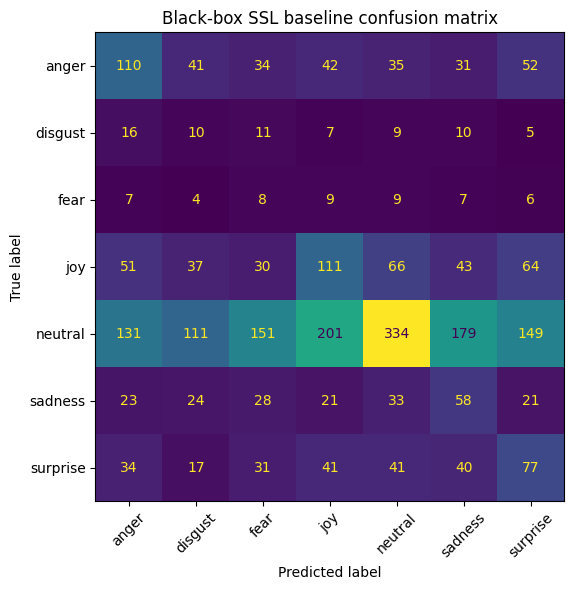

In [14]:
# Black-box baseline: frozen HuBERT embeddings are passed directly to an emotion classifier.
# This model has no built-in human-interpretable bottleneck.

blackbox_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
])
blackbox_model.fit(X_train_ssl, y_train)
blackbox_pred = blackbox_model.predict(X_test_ssl)
blackbox_proba = blackbox_model.predict_proba(X_test_ssl)
blackbox_metrics = safe_macro_metrics(y_test, blackbox_pred)

print("Black-box SSL baseline metrics")
display(pd.DataFrame([blackbox_metrics]))
print(classification_report(y_test, blackbox_pred, target_names=class_names, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, blackbox_pred, labels=np.arange(len(class_names)))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Black-box SSL baseline confusion matrix")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "blackbox_ssl_confusion_matrix.png", dpi=200)
plt.show()


CBM metrics using predicted concepts


,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,0.234483,0.192401,0.263494,0.214452,0.244873


              precision    recall  f1-score   support

       anger       0.28      0.32      0.30       345
     disgust       0.05      0.35      0.09        68
        fear       0.04      0.12      0.06        50
         joy       0.22      0.15      0.18       402
     neutral       0.60      0.22      0.32      1256
     sadness       0.15      0.29      0.20       208
    surprise       0.17      0.25      0.20       281

    accuracy                           0.23      2610
   macro avg       0.21      0.24      0.19      2610
weighted avg       0.39      0.23      0.26      2610

Oracle concept upper-bound metrics


,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,0.222222,0.184944,0.254468,0.215505,0.221754


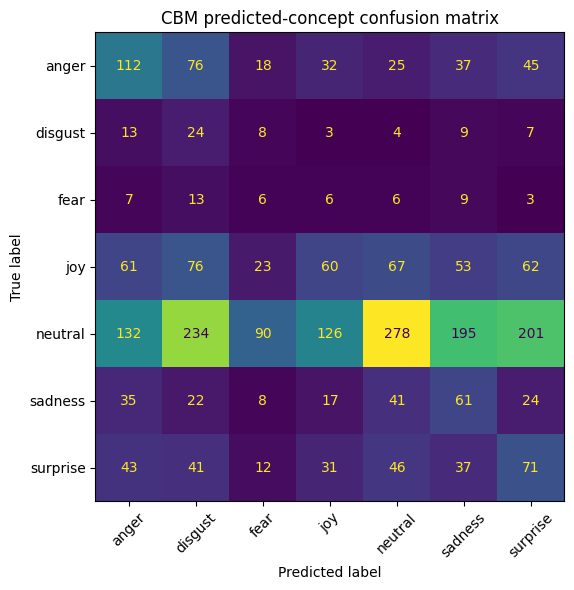

In [15]:
# Concept Bottleneck Model.
# Stage 1 maps HuBERT embeddings to acoustic proxy concepts.
# Stage 2 predicts emotion labels from the concept vector.

concept_scaler = StandardScaler()
C_train = concept_scaler.fit_transform(X_train_concepts_raw)
C_test_oracle = concept_scaler.transform(X_test_concepts_raw)

# Concept predictor: estimate standardized acoustic concepts from SSL embeddings.
concept_predictor = Pipeline([
    ("ssl_scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0, random_state=RANDOM_STATE))
])
concept_predictor.fit(X_train_ssl, C_train)
C_train_pred = concept_predictor.predict(X_train_ssl)
C_test_pred = concept_predictor.predict(X_test_ssl)

# The classifier is trained on extracted concepts; at test time, the CBM uses predicted concepts.
concept_classifier = Pipeline([
    ("concept_clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
])
concept_classifier.fit(C_train, y_train)

cbm_pred = concept_classifier.predict(C_test_pred)
cbm_proba = concept_classifier.predict_proba(C_test_pred)
cbm_metrics = safe_macro_metrics(y_test, cbm_pred)

# Oracle concept classifier: evaluates performance when extracted concepts are directly available at test time.
oracle_pred = concept_classifier.predict(C_test_oracle)
oracle_metrics = safe_macro_metrics(y_test, oracle_pred)

print("CBM metrics using predicted concepts")
display(pd.DataFrame([cbm_metrics]))
print(classification_report(y_test, cbm_pred, target_names=class_names, zero_division=0))

print("Oracle concept upper-bound metrics")
display(pd.DataFrame([oracle_metrics]))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, cbm_pred, labels=np.arange(len(class_names)))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("CBM predicted-concept confusion matrix")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cbm_confusion_matrix.png", dpi=200)
plt.show()


In [16]:
# Evaluate how well each acoustic concept can be predicted from HuBERT embeddings.

from sklearn.metrics import r2_score, mean_absolute_error

r2_values = []
for j, concept in enumerate(concept_cols):
    r2_values.append({
        "concept": concept,
        "r2_test": r2_score(C_test_oracle[:, j], C_test_pred[:, j]),
        "mae_test_scaled": mean_absolute_error(C_test_oracle[:, j], C_test_pred[:, j]),
    })
concept_quality = pd.DataFrame(r2_values).sort_values("r2_test", ascending=False)
concept_quality.to_csv(OUTPUT_DIR / "concept_prediction_quality.csv", index=False)
display(concept_quality.head(15))


,concept,r2_test,mae_test_scaled
0,duration,0.900665,0.228996
14,mfcc_1_std,0.852692,0.289119
5,pitch_proxy_std,0.803976,0.329433
16,mfcc_2_std,0.763182,0.373392
18,mfcc_3_std,0.689234,0.433030
17,mfcc_3_mean,0.676331,0.443612
20,mfcc_4_std,0.635707,0.485646
22,mfcc_5_std,0.590311,0.496785
24,mfcc_6_std,0.544784,0.536449
21,mfcc_5_mean,0.543389,0.531646


,concept,mean_abs_shap
8,spectral_centroid_mean,0.029871
10,spectral_rolloff_mean,0.025698
9,spectral_bandwidth_mean,0.024670
15,mfcc_2_mean,0.019517
13,mfcc_1_mean,0.017521
5,pitch_proxy_std,0.013625
17,mfcc_3_mean,0.012672
4,pitch_proxy_mean,0.011624
7,zero_crossing_rate_mean,0.011551
16,mfcc_2_std,0.011388


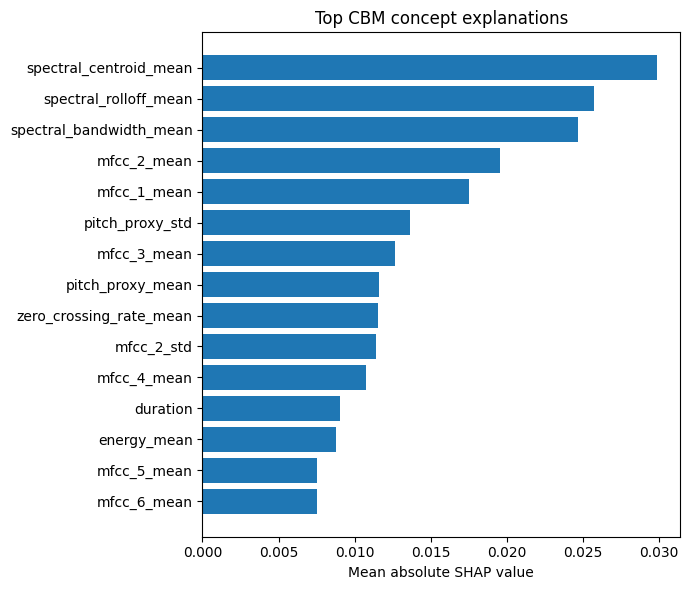

In [17]:
# Explain the CBM using SHAP values over acoustic concepts.
# The explanation targets the concept-to-emotion classifier rather than raw HuBERT dimensions.

if shap is None:
    raise RuntimeError("Install SHAP first: pip install shap")

rng = np.random.default_rng(RANDOM_STATE)
background_size = min(80, len(C_train))
explain_size = min(80, len(C_test_pred))
background_idx = rng.choice(len(C_train), size=background_size, replace=False)
explain_idx = rng.choice(len(C_test_pred), size=explain_size, replace=False)

C_background = pd.DataFrame(C_train[background_idx], columns=concept_cols)
C_explain = pd.DataFrame(C_test_pred[explain_idx], columns=concept_cols)

def cbm_predict_proba_from_concepts(data):
    if isinstance(data, pd.DataFrame):
        arr = data[concept_cols].to_numpy()
    else:
        arr = np.asarray(data)
    return concept_classifier.predict_proba(arr)

explainer = shap.Explainer(cbm_predict_proba_from_concepts, C_background)
shap_values = explainer(C_explain)

# For multi-class SHAP outputs, aggregate absolute values across samples and classes.
values = np.asarray(shap_values.values)
if values.ndim == 3:
    importance = np.abs(values).mean(axis=(0, 2))
else:
    importance = np.abs(values).mean(axis=0)

shap_importance = pd.DataFrame({
    "concept": concept_cols,
    "mean_abs_shap": importance,
}).sort_values("mean_abs_shap", ascending=False)
shap_importance.to_csv(OUTPUT_DIR / "cbm_concept_shap_importance.csv", index=False)
display(shap_importance.head(20))

fig, ax = plt.subplots(figsize=(7, 6))
plot_df = shap_importance.head(15).iloc[::-1]
ax.barh(plot_df["concept"], plot_df["mean_abs_shap"])
ax.set_xlabel("Mean absolute SHAP value")
ax.set_title("Top CBM concept explanations")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cbm_concept_shap_bar.png", dpi=200)
plt.show()


In [18]:
# Faithfulness evaluation through concept ablation.
# A faithful ranking should produce a larger performance drop than random concept ablation.

def evaluate_concept_ablation(C_base, concepts_to_ablate):
    C_mod = C_base.copy()
    for concept in concepts_to_ablate:
        if concept in concept_cols:
            j = concept_cols.index(concept)
            # Concepts are standardized; setting a value to zero replaces it with the training mean.
            C_mod[:, j] = 0.0
    pred = concept_classifier.predict(C_mod)
    metrics = safe_macro_metrics(y_test, pred)
    return metrics

baseline_cbm = safe_macro_metrics(y_test, cbm_pred)
faithfulness_rows = []
faithfulness_random_runs = []

for k in [1, 3, 5, 10]:
    k = min(k, len(concept_cols))
    top_concepts = shap_importance.head(k)["concept"].tolist()
    top_metrics = evaluate_concept_ablation(C_test_pred, top_concepts)
    faithfulness_rows.append({
        "ablation": f"top_{k}_shap_concepts",
        "concepts": ", ".join(top_concepts),
        "n_concepts": k,
        "accuracy_drop": baseline_cbm["accuracy"] - top_metrics["accuracy"],
        "accuracy_drop_std": np.nan,
        "macro_f1_drop": baseline_cbm["macro_f1"] - top_metrics["macro_f1"],
        "macro_f1_drop_std": np.nan,
    })

    # Average across several random concept sets of the same size.
    random_drops = []
    for rep in range(20):
        random_concepts = rng.choice(concept_cols, size=k, replace=False).tolist()
        random_metrics = evaluate_concept_ablation(C_test_pred, random_concepts)
        acc_drop = baseline_cbm["accuracy"] - random_metrics["accuracy"]
        f1_drop = baseline_cbm["macro_f1"] - random_metrics["macro_f1"]
        random_drops.append((acc_drop, f1_drop))
        faithfulness_random_runs.append({
            "n_concepts": k,
            "rep": rep,
            "concepts": ", ".join(random_concepts),
            "accuracy_drop": float(acc_drop),
            "macro_f1_drop": float(f1_drop),
        })

    random_drops = np.asarray(random_drops)
    faithfulness_rows.append({
        "ablation": f"random_{k}_concepts_mean_20_runs",
        "concepts": "random",
        "n_concepts": k,
        "accuracy_drop": float(random_drops[:, 0].mean()),
        "accuracy_drop_std": float(random_drops[:, 0].std(ddof=1)),
        "macro_f1_drop": float(random_drops[:, 1].mean()),
        "macro_f1_drop_std": float(random_drops[:, 1].std(ddof=1)),
    })

faithfulness_table = pd.DataFrame(faithfulness_rows)
faithfulness_random_runs = pd.DataFrame(faithfulness_random_runs)

# Save both a backward-compatible filename and a clearer report-ready filename.
faithfulness_table.to_csv(OUTPUT_DIR / "cbm_faithfulness_ablation.csv", index=False)
faithfulness_table.to_csv(OUTPUT_DIR / "cbm_faithfulness_ablation_with_std.csv", index=False)
faithfulness_random_runs.to_csv(OUTPUT_DIR / "cbm_faithfulness_random_ablation_runs.csv", index=False)

display(faithfulness_table)


,ablation,concepts,n_concepts,accuracy_drop,accuracy_drop_std,macro_f1_drop,macro_f1_drop_std
0,top_1_shap_concepts,spectral_centroid_mean,1,-0.004598,NaN,0.014065,NaN
1,random_1_concepts_mean_20_runs,random,1,0.001513,0.014583,0.001599,0.007276
2,top_3_shap_concepts,"spectral_centroid_mean, spectral_rolloff_mean,...",3,0.008812,NaN,0.021693,NaN
3,random_3_concepts_mean_20_runs,random,3,0.014559,0.017822,0.010150,0.009002
4,top_5_shap_concepts,"spectral_centroid_mean, spectral_rolloff_mean,...",5,0.041762,NaN,0.038434,NaN
5,random_5_concepts_mean_20_runs,random,5,0.018027,0.021435,0.018712,0.010991
6,top_10_shap_concepts,"spectral_centroid_mean, spectral_rolloff_mean,...",10,0.000766,NaN,0.024566,NaN
7,random_10_concepts_mean_20_runs,random,10,0.032969,0.020712,0.028324,0.011826


In [19]:
# Group top-ranked concepts into interpretable acoustic families.

def concept_family(name):
    if name.startswith("pitch") or name.startswith("voiced_ratio"):
        return "pitch / voicing"
    if name.startswith("energy") or name == "pause_ratio" or name == "duration":
        return "energy / pauses / timing"
    if name.startswith("mfcc"):
        return "cepstral / vocal tract shape"
    if name.startswith("spectral") or name.startswith("zero"):
        return "spectral shape / noisiness"
    if name.startswith("onset"):
        return "speaking-rate proxy"
    return "other"


domain_alignment = shap_importance.copy()
domain_alignment["speech_concept_family"] = domain_alignment["concept"].apply(concept_family)

domain_alignment.to_csv(OUTPUT_DIR / "cbm_domain_alignment.csv", index=False)

display(domain_alignment.head(20))

display(
    domain_alignment
    .groupby("speech_concept_family")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

,concept,mean_abs_shap,speech_concept_family
8,spectral_centroid_mean,0.029871,spectral shape / noisiness
10,spectral_rolloff_mean,0.025698,spectral shape / noisiness
9,spectral_bandwidth_mean,0.024670,spectral shape / noisiness
15,mfcc_2_mean,0.019517,cepstral / vocal tract shape
13,mfcc_1_mean,0.017521,cepstral / vocal tract shape
5,pitch_proxy_std,0.013625,pitch / voicing
17,mfcc_3_mean,0.012672,cepstral / vocal tract shape
4,pitch_proxy_mean,0.011624,pitch / voicing
7,zero_crossing_rate_mean,0.011551,spectral shape / noisiness
16,mfcc_2_std,0.011388,cepstral / vocal tract shape


,mean_abs_shap
speech_concept_family,
cepstral / vocal tract shape,0.166416
spectral shape / noisiness,0.097712
energy / pauses / timing,0.030706
pitch / voicing,0.029710
speaking-rate proxy,0.002978


In [20]:
# Concept intervention analysis.
# Interventions measure how controlled concept changes affect CBM predictions.

coef = concept_classifier.named_steps["concept_clf"].coef_  # [classes, concepts]
intervention_rows = []

top_intervention_concepts = shap_importance.head(5)["concept"].tolist()
examples = np.arange(min(10, len(C_test_pred)))

for i in examples:
    original = C_test_pred[i:i+1].copy()
    original_proba = concept_classifier.predict_proba(original)[0]
    original_class_idx = int(np.argmax(original_proba))

    for concept in top_intervention_concepts:
        j = concept_cols.index(concept)
        # Shift the concept in the direction favored by the currently predicted class.
        direction = 1.0 if coef[original_class_idx, j] >= 0 else -1.0
        modified = original.copy()
        modified[0, j] += direction * 1.0  # one standardized unit
        modified_proba = concept_classifier.predict_proba(modified)[0]
        new_class_idx = int(np.argmax(modified_proba))
        intervention_rows.append({
            "sample_index_in_test": int(i),
            "true_label": class_names[int(y_test[i])],
            "original_prediction": class_names[original_class_idx],
            "intervened_concept": concept,
            "intervention": "+1 std" if direction > 0 else "-1 std",
            "new_prediction": class_names[new_class_idx],
            "original_predicted_class_probability": float(original_proba[original_class_idx]),
            "new_original_class_probability": float(modified_proba[original_class_idx]),
            "probability_change_for_original_class": float(modified_proba[original_class_idx] - original_proba[original_class_idx]),
        })

intervention_table = pd.DataFrame(intervention_rows)
intervention_table.to_csv(OUTPUT_DIR / "cbm_concept_interventions.csv", index=False)
display(intervention_table.head(30))


,sample_index_in_test,true_label,original_prediction,intervened_concept,intervention,new_prediction,original_predicted_class_probability,new_original_class_probability,probability_change_for_original_class
0,0,surprise,neutral,spectral_centroid_mean,+1 std,neutral,0.185898,0.281453,0.095555
1,0,surprise,neutral,spectral_rolloff_mean,-1 std,fear,0.185898,0.173582,-0.012316
2,0,surprise,neutral,spectral_bandwidth_mean,+1 std,sadness,0.185898,0.175475,-0.010423
3,0,surprise,neutral,mfcc_2_mean,+1 std,neutral,0.185898,0.243145,0.057247
4,0,surprise,neutral,mfcc_1_mean,-1 std,sadness,0.185898,0.184771,-0.001127
5,1,anger,disgust,spectral_centroid_mean,-1 std,disgust,0.187563,0.239510,0.051947
6,1,anger,disgust,spectral_rolloff_mean,+1 std,anger,0.187563,0.227390,0.039827
7,1,anger,disgust,spectral_bandwidth_mean,-1 std,anger,0.187563,0.207857,0.020294
8,1,anger,disgust,mfcc_2_mean,+1 std,disgust,0.187563,0.209722,0.022159
9,1,anger,disgust,mfcc_1_mean,+1 std,anger,0.187563,0.200767,0.013204


In [21]:
# Save the final comparison table for black-box and explainable models.

comparison = pd.DataFrame([
    {
        "model": "Black-box SSL classifier",
        "input": "wav2vec/HuBERT frozen embedding",
        "backbone": BACKBONE_NAME,
        "explanation_type": "none by design; optional post-hoc only",
        **blackbox_metrics,
    },
    {
        "model": "Concept Bottleneck Model",
        "input": "SSL embedding -> predicted acoustic proxy concepts -> classifier",
        "backbone": BACKBONE_NAME,
        "explanation_type": "explainable by design + SHAP over concepts + interventions",
        **cbm_metrics,
    },
    {
        "model": "Oracle concept classifier upper bound",
        "input": "extracted acoustic proxy concepts directly",
        "backbone": "no SSL prediction step at test time",
        "explanation_type": "concept-level upper bound reference",
        **oracle_metrics,
    },
])
comparison.to_csv(OUTPUT_DIR / "blackbox_vs_explainable_comparison.csv", index=False)
display(comparison)


,model,input,backbone,explanation_type,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,Black-box SSL classifier,wav2vec/HuBERT frozen embedding,facebook/hubert-base-ls960,none by design; optional post-hoc only,0.271264,0.213561,0.305775,0.231171,0.245830
1,Concept Bottleneck Model,SSL embedding -> predicted acoustic proxy conc...,facebook/hubert-base-ls960,explainable by design + SHAP over concepts + i...,0.234483,0.192401,0.263494,0.214452,0.244873
2,Oracle concept classifier upper bound,extracted acoustic proxy concepts directly,no SSL prediction step at test time,concept-level upper bound reference,0.222222,0.184944,0.254468,0.215505,0.221754


## Majority Baseline and Bootstrap Evaluation

This section computes the additional evaluation artifacts used for the final report:

- a majority-class baseline;
- bootstrap confidence intervals for accuracy and macro-F1;
- paired bootstrap tests for model-comparison gaps;
- report-ready summary tables for the main experimental results.


In [22]:
# Compute majority baseline metrics, bootstrap confidence intervals, and paired bootstrap tests.

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

N_BOOTSTRAP = 1000
BOOTSTRAP_RANDOM_STATE = RANDOM_STATE
rng_boot = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)

# Majority-class baseline; for MELD this is usually neutral, but the implementation remains data-driven.
if "neutral" in class_names:
    majority_class_idx = class_names.index("neutral")
else:
    majority_class_idx = int(pd.Series(y_train).value_counts().idxmax())

majority_pred = np.full_like(y_test, fill_value=majority_class_idx)

model_predictions = {
    "Majority neutral" if class_names[majority_class_idx] == "neutral" else "Majority class": majority_pred,
    "Black-box HuBERT": blackbox_pred,
    "CBM": cbm_pred,
    "Oracle concepts": oracle_pred,
}

def report_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_bootstrap=N_BOOTSTRAP, rng=rng_boot):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    values = np.empty(n_bootstrap, dtype=float)
    for b in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        values[b] = metric_fn(y_true[idx], y_pred[idx])
    return float(np.percentile(values, 2.5)), float(np.percentile(values, 97.5)), values

metric_functions = {
    "accuracy": lambda yt, yp: accuracy_score(yt, yp),
    "macro_f1": lambda yt, yp: f1_score(yt, yp, average="macro", zero_division=0),
}

# Report table: point estimates with 95% confidence intervals for accuracy and macro-F1.
bootstrap_rows = []
bootstrap_distributions = {}

for model_name, pred in model_predictions.items():
    point = report_metrics(y_test, pred)
    row = {"model": model_name, **point}
    for metric_name, metric_fn in metric_functions.items():
        lo, hi, values = bootstrap_metric_ci(y_test, pred, metric_fn)
        row[f"{metric_name}_ci_low"] = lo
        row[f"{metric_name}_ci_high"] = hi
        bootstrap_distributions[(model_name, metric_name)] = values
    bootstrap_rows.append(row)

bootstrap_ci_table = pd.DataFrame(bootstrap_rows)
bootstrap_ci_table.to_csv(OUTPUT_DIR / "bootstrap_confidence_intervals.csv", index=False)

# Save a standalone majority-baseline file for traceability.
majority_baseline_metrics = bootstrap_ci_table[bootstrap_ci_table["model"].str.startswith("Majority")].copy()
majority_baseline_metrics.to_csv(OUTPUT_DIR / "majority_baseline_metrics.csv", index=False)

# Paired bootstrap gap tests resample the same test indices for both models.
def paired_bootstrap_gap_ci(y_true, pred_a, pred_b, metric_fn, n_bootstrap=N_BOOTSTRAP, rng=None):
    rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE) if rng is None else rng
    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    n = len(y_true)
    gaps = np.empty(n_bootstrap, dtype=float)
    for b in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        gaps[b] = metric_fn(y_true[idx], pred_a[idx]) - metric_fn(y_true[idx], pred_b[idx])
    return float(gaps.mean()), float(np.percentile(gaps, 2.5)), float(np.percentile(gaps, 97.5))

paired_tests = [
    ("Black-box HuBERT", "CBM", blackbox_pred, cbm_pred),
    ("CBM", "Oracle concepts", cbm_pred, oracle_pred),
]

gap_rows = []
for model_a, model_b, pred_a, pred_b in paired_tests:
    for metric_name, metric_fn in metric_functions.items():
        point_gap = metric_fn(y_test, pred_a) - metric_fn(y_test, pred_b)
        mean_gap, lo, hi = paired_bootstrap_gap_ci(
            y_test, pred_a, pred_b, metric_fn,
            n_bootstrap=N_BOOTSTRAP,
            rng=np.random.default_rng(BOOTSTRAP_RANDOM_STATE),
        )
        gap_rows.append({
            "model_a": model_a,
            "model_b": model_b,
            "metric": metric_name,
            "point_gap_a_minus_b": float(point_gap),
            "bootstrap_mean_gap": mean_gap,
            "ci_low": lo,
            "ci_high": hi,
            "distinguishable_from_zero_95ci": bool((lo > 0) or (hi < 0)),
        })

paired_gap_table = pd.DataFrame(gap_rows)
paired_gap_table.to_csv(OUTPUT_DIR / "paired_bootstrap_gap_tests.csv", index=False)

# Create report-ready display strings for the final table.
report_table_2 = bootstrap_ci_table[[
    "model", "accuracy", "accuracy_ci_low", "accuracy_ci_high",
    "macro_f1", "macro_f1_ci_low", "macro_f1_ci_high", "weighted_f1"
]].copy()

report_table_2["Accuracy"] = report_table_2.apply(
    lambda r: f"{r['accuracy']:.3f} [{r['accuracy_ci_low']:.3f},{r['accuracy_ci_high']:.3f}]", axis=1
)
report_table_2["Macro-F1"] = report_table_2.apply(
    lambda r: f"{r['macro_f1']:.3f} [{r['macro_f1_ci_low']:.3f},{r['macro_f1_ci_high']:.3f}]", axis=1
)
report_table_2["W-F1"] = report_table_2["weighted_f1"].map(lambda x: f"{x:.3f}")
report_table_2 = report_table_2[["model", "Accuracy", "Macro-F1", "W-F1"]]
report_table_2.to_csv(OUTPUT_DIR / "report_table_2_with_bootstrap_ci.csv", index=False)

print("Saved statistical outputs:")
print("- majority_baseline_metrics.csv")
print("- bootstrap_confidence_intervals.csv")
print("- paired_bootstrap_gap_tests.csv")
print("- report_table_2_with_bootstrap_ci.csv")

display(report_table_2)
display(paired_gap_table)


Saved statistical outputs:
- majority_baseline_metrics.csv
- bootstrap_confidence_intervals.csv
- paired_bootstrap_gap_tests.csv
- report_table_2_with_bootstrap_ci.csv


,model,Accuracy,Macro-F1,W-F1
0,Majority neutral,"0.481 [0.462,0.500]","0.093 [0.090,0.095]",0.313
1,Black-box HuBERT,"0.271 [0.254,0.287]","0.214 [0.198,0.229]",0.306
2,CBM,"0.234 [0.218,0.251]","0.192 [0.177,0.207]",0.263
3,Oracle concepts,"0.222 [0.207,0.237]","0.185 [0.171,0.200]",0.254


,model_a,model_b,metric,point_gap_a_minus_b,bootstrap_mean_gap,ci_low,ci_high,distinguishable_from_zero_95ci
0,Black-box HuBERT,CBM,accuracy,0.036782,0.036838,0.014943,0.057107,True
1,Black-box HuBERT,CBM,macro_f1,0.021160,0.021291,0.002007,0.041116,True
2,CBM,Oracle concepts,accuracy,0.012261,0.012032,-0.005747,0.030278,False
3,CBM,Oracle concepts,macro_f1,0.007457,0.007128,-0.008231,0.022683,False


In [23]:
# Save a compact reproducibility summary and list generated artifacts.

summary = {
    "meld_root": str(MELD_ROOT),
    "backbone": BACKBONE_NAME,
    "label_mode": LABEL_MODE,
    "quick_run": QUICK_RUN,
    "max_items_per_split": MAX_ITEMS_PER_SPLIT if QUICK_RUN else None,
    "classes": class_names,
    "n_samples": int(len(meld_index)),
    "n_train": int(train_idx.sum()),
    "n_test": int(test_idx.sum()),
    "n_concepts": int(len(concept_cols)),
    "concepts": concept_cols,
    "blackbox_metrics": blackbox_metrics,
    "cbm_metrics": cbm_metrics,
    "oracle_concept_metrics": oracle_metrics,
}
save_json(summary, OUTPUT_DIR / "final_reproducibility_config.json")

print('Saved outputs in Google Drive/local path:', OUTPUT_DIR)
print("Main files:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path.name)
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print("-", path.name)
print("- final_reproducibility_config.json")


Saved outputs in Google Drive/local path: /content/drive/MyDrive/XAI_MELD_Project/outputs/meld_ssl_cbm_xai
Main files:
- blackbox_vs_explainable_comparison.csv
- bootstrap_confidence_intervals.csv
- cbm_concept_interventions.csv
- cbm_concept_shap_importance.csv
- cbm_domain_alignment.csv
- cbm_faithfulness_ablation.csv
- cbm_faithfulness_ablation_with_std.csv
- cbm_faithfulness_random_ablation_runs.csv
- concept_prediction_quality.csv
- ffmpeg_failed_media.csv
- majority_baseline_metrics.csv
- meld_acoustic_proxy_concepts.csv
- meld_acoustic_proxy_concepts_fast.csv
- meld_audio_index.csv
- meld_audio_index_with_wavs.csv
- missing_media_rows.csv
- paired_bootstrap_gap_tests.csv
- report_table_2_with_bootstrap_ci.csv
- blackbox_ssl_confusion_matrix.png
- cbm_concept_shap_bar.png
- cbm_confusion_matrix.png
- final_reproducibility_config.json
